<a href="https://colab.research.google.com/github/Kumar2004-2009/AI_ML/blob/main/flow_of_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [13]:
df=pd.read_csv("placement.csv")

In [14]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [15]:
df.shape

(100, 4)

In [16]:
#Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/ model selection
# 6. Deploy the model


In [17]:
df=df.iloc[:,1:]

In [18]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [19]:
import matplotlib.pyplot as plt


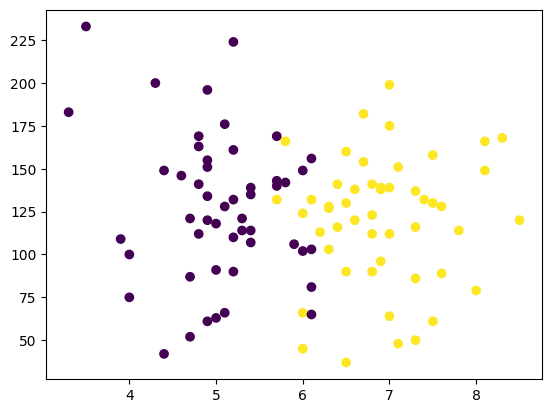

In [21]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [22]:
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]

In [24]:
from sklearn.model_selection import train_test_split

# 10% data for testing
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.1)

In [25]:
X_train

,cgpa,iq
29,7.0,112.0
86,5.1,128.0
80,4.9,196.0
28,5.2,90.0
36,5.7,140.0
...,...,...
22,4.9,120.0
63,6.3,128.0
91,7.5,158.0
83,7.5,130.0


In [26]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [27]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [28]:
X_train

array([[ 0.90922614, -0.36488025],
       [-0.76437633,  0.06160316],
       [-0.94054502,  1.87415765],
       [-0.67629199, -0.95129494],
       [-0.23587029,  0.38146572],
       [-1.1167137 , -0.12498333],
       [-0.94054502,  0.22153444],
       [-0.14778595,  0.43477614],
       [ 0.29263575, -0.60477717],
       [-0.94054502,  0.78129391],
       [-0.85246068, -1.6709857 ],
       [ 0.8211418 ,  0.32815529],
       [-1.46905106,  1.98077851],
       [-0.50012331, -0.31156982],
       [ 0.90922614, -1.64433048],
       [-0.67629199,  0.16822401],
       [-1.02862936, -0.36488025],
       [-1.38096672,  0.62136264],
       [ 0.02838273, -1.59102006],
       [-0.76437633,  1.34105339],
       [-0.50012331, -0.49815632],
       [ 0.73305746, -0.07167291],
       [ 0.46880444, -0.95129494],
       [ 0.73305746,  0.40812093],
       [ 0.11646707, -0.60477717],
       [ 1.17347916, -0.2582594 ],
       [ 0.46880444,  0.91456998],
       [ 1.87815389,  1.07450126],
       [-0.50012331,

In [29]:
X_test

array([[ 0.90922614,  1.95412329],
       [-0.67629199,  0.94122519],
       [ 0.11646707, -1.61767527],
       [ 1.34964784, -1.72429612],
       [-0.85246068, -0.92463973],
       [ 1.43773218, -0.97795015],
       [ 1.43773218,  0.06160316],
       [-1.02862936,  0.99453562],
       [ 0.46880444, -2.36402124],
       [-1.1167137 , -1.96419304]])

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
clf=LogisticRegression()

In [32]:
#model training
clf.fit(X_train,y_train)

LogisticRegression()

In [35]:
y_predict=clf.predict(X_test)

In [36]:
y_test

,placement
26,1
47,0
56,0
44,1
25,0
42,1
30,1
34,0
82,1
94,0


In [37]:
from sklearn.metrics import accuracy_score

In [38]:
accuracy_score(y_test,y_predict)

0.9

In [42]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

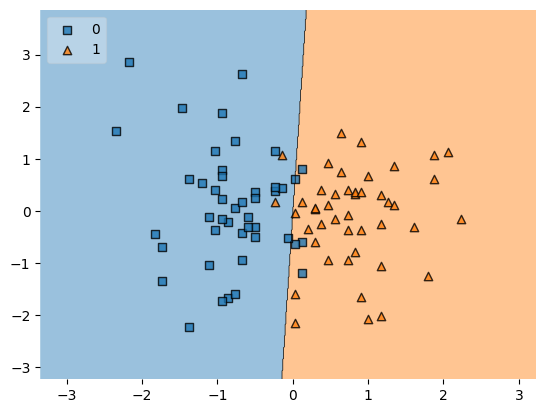

In [43]:
#x_tain and y_train must be of numpy
plot_decision_regions(X_train,y_train.values,clf=clf,legend=2)

In [44]:
import pickle

In [45]:
pickle.dump(clf,open('model.pkl','wb'))